# 2023 Singapore GP(Marina Bay) - Strategy Post-Mortem: Managing Pace to Manage a Race

## The Racing Question:
Carlos Sainz led the entire 2023 Singapore GP from pole position, and Red Bull's season long dominance meant nobody expected a real threat. Yet the final laps saw the two Mercedes cars (Lewis Hamilton & George Russell) closing fast on fresh tires, one crashing during the pursuit. How did Sainz's strategy and his final-laps tactics hold off a genuine late charge to victory?

## What Happened:
 - Sainz(driving for Ferrari) deliberately drove below his car's potential pace in the early laps, managing his tires specifically to make a one-stop strategy viable for the whole race distance.
 - Lap 20: A Safety Car (triggered by Sargent's crash) prompts Sainz, Norris, and Leclerc to pit for Hard tires; a stop they'd have needed soon regardless(effectively "free" when under a Safety Car).
 - Laps 20-43: a long, stable middle stint. Norris and Russell both run close behind Sainz (within 0-4s), no major swings.
 - Lap 44: Mercedes make a bold, late strategic gamble, pitting Russell under the Virtual Safety Car for fresh Mediums; sacrificing track position(dropping ~17.5s behind Sainz) to bank a large tire life and compound advantage for the closing laps.
 - Laps 44-61: the gamble nearly pays off. Russell closes the gap from ~17.5s down to ~1.5s behind the lead group, a genuine fresh tire recovery, not just incremental gains.
 Throughout the closing laps, Norri's gap to Sainz stays remarkably flat(~1-2s) and this wasn't incidental. Sainz deliberately slowed to keep Norris within DRS range, turning Norris into a defensive shield. The DRS-aided McLaren was able to hold off the faster Mercedes cars behind it, which in turn protected Sainz's lead. 
 - On the final lap(lap 62), Russell crashed at Turn 10 attempting to pass Norris for second place, ending his charge and promoting Hamilton to the final podium spot.

 ## Why It Matters:
 This race wasn't decided by a single pit call or a single tire read; it was decided by a strategy with two distinct phases: early pace-management to make a one-stop strategy viable, and late-race defensive tactics that used a *rival's* car as a tool. Mercedes's late gamble was legitimate, well-excecuted strategic threat that very nearly worked; it was ultimately neutralized by Sainz's proactive defensive tactics, not my Mercedes making an error.

 ## Strategist Takeaway:
 Strategy doesn't end once the tire calls are made. A lead built on a one-stop plan is only as strong as the driver's ability to defend it in real time once a rival's undercut/overcut threat materializes; and sometimes the most effective defensive tool isn't your own pace, it's positioning a slower car ahead of you as a shield against a faster one behind. Recognizing and using that dynamic in the moment is itself a strategic skill, not just a driving one.

 ## A Note on Method:
 Two things were worth double-checking rather than assuming in this analysis. First, an early check of Russell's pit stop compounds initially looked inconsistent with the race recap, until it became clear FastF1 records the *outgoing* tire on the pit-in row, not the incoming one; confirmed directly against the following lap's data. 
 Second, an anomalous ~51s gap on Russell's final lap was initally assumed to be 'NaT'- related data artifact from his DNF, but double-checking the underlying value showed it was a real, valid timestamp, just one that captured his car's position mid-crash rather than a completed lap. The lesson holds either way; verify an assumption about *why* something looks wrong before writing it into an analysis, rather than trusting a plausible-sounding first guess. 

In [1]:
#imports
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fastf1.Cache.enable_cache('../data/cache')

session = fastf1.get_session(2023, 'Singapore', 'R')
session.load()

print(session.event['EventName'])
print(session.event['EventDate'])

core           INFO 	Loading data for Singapore Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

Singapore Grand Prix
2023-09-17 00:00:00


In [3]:
#Getting lap data for Sainz, Russell and Norris
laps = session.laps

sai_laps = laps.pick_drivers('SAI')
rus_laps = laps.pick_drivers('RUS')
nor_laps = laps.pick_drivers('NOR')

print("Sainz Laps: ", len(sai_laps))
print("Russell Laps: ", len(rus_laps))
print("Norris Laps: ", len(nor_laps))

cols = ['LapNumber', 'LapTime', 'Compound', 'PitInTime', 'PitOutTime', 'TrackStatus']

Sainz Laps:  62
Russell Laps:  62
Norris Laps:  62


In [4]:
#checking to see why RUS finished 62 laps if he crashed on the last lap

print(rus_laps[['LapNumber', 'LapTime', 'TrackStatus']].tail(5))

     LapNumber                LapTime TrackStatus
969       58.0 0 days 00:01:38.686000           1
970       59.0 0 days 00:01:40.239000          12
971       60.0 0 days 00:01:39.510000           1
972       61.0 0 days 00:01:39.314000           1
973       62.0                    NaT          12


In [5]:
#Studying the pitstops for SAI, NOR, and RUS:

sai_pit_laps = sai_laps[sai_laps['PitInTime'].notna()]
nor_pit_laps = nor_laps[nor_laps['PitInTime'].notna()]
rus_pit_laps = rus_laps[rus_laps['PitInTime'].notna()]

print("Sainz pit stops:")
print(sai_pit_laps[cols])

print("\nNorris pit stops:")
print(nor_pit_laps[cols])

print("\nRussell pit stops:")
print(rus_pit_laps[cols])

Sainz pit stops:
     LapNumber                LapTime Compound              PitInTime  \
869       20.0 0 days 00:01:56.824000   MEDIUM 0 days 01:36:19.344000   

    PitOutTime TrackStatus  
869        NaT          14  

Norris pit stops:
     LapNumber                LapTime Compound              PitInTime  \
683       20.0 0 days 00:02:01.158000   MEDIUM 0 days 01:36:31.281000   

    PitOutTime TrackStatus  
683        NaT          14  

Russell pit stops:
     LapNumber                LapTime Compound              PitInTime  \
931       20.0 0 days 00:02:00.405000   MEDIUM 0 days 01:36:29.437000   
955       44.0 0 days 00:02:24.887000     HARD 0 days 02:19:21.923000   

    PitOutTime TrackStatus  
931        NaT          14  
955        NaT          26  


In [6]:
print(rus_laps[rus_laps['LapNumber'].isin([21, 45])][['LapNumber', 'Compound']])

     LapNumber Compound
932       21.0     HARD
956       45.0   MEDIUM


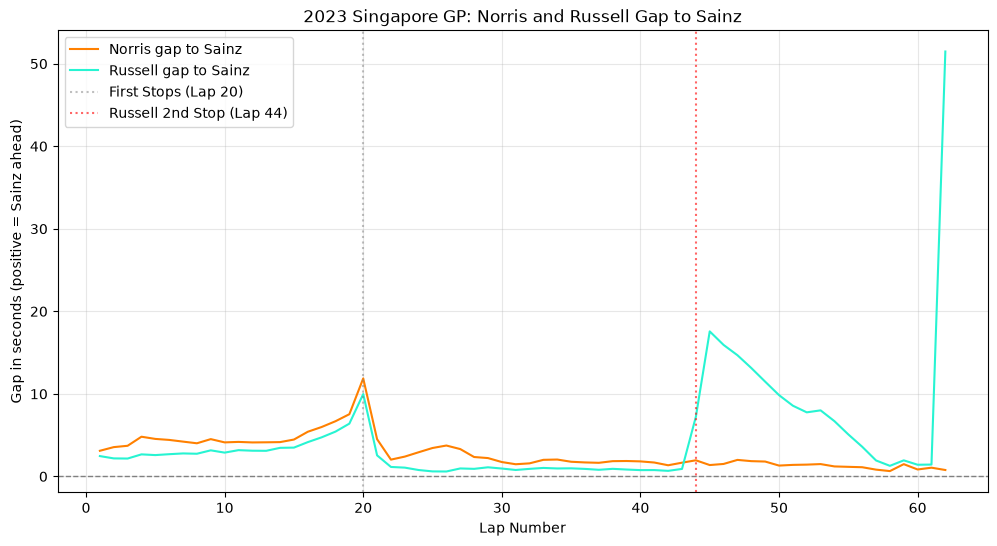

In [7]:
#three way gap chart for SAI, NOR, and RUS:

merged = pd.merge(sai_laps[['LapNumber', 'Time']], nor_laps[['LapNumber', 'Time']], on='LapNumber', suffixes=('_SAI', '_NOR'))
merged = pd.merge(merged, rus_laps[['LapNumber', 'Time']], on='LapNumber')
merged = merged.rename(columns={'Time': 'Time_RUS'})

merged['Gap_NOR_to_SAI'] = (merged['Time_NOR'] - merged['Time_SAI']).dt.total_seconds()
merged['Gap_RUS_to_SAI'] = (merged['Time_RUS'] - merged['Time_SAI']).dt.total_seconds()

plt.figure(figsize=(12, 6))
plt.plot(merged['LapNumber'], merged['Gap_NOR_to_SAI'], color='#FF8000', label='Norris gap to Sainz')
plt.plot(merged['LapNumber'], merged['Gap_RUS_to_SAI'], color='#27F4D2', label='Russell gap to Sainz')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.axvline(20, color='gray', linestyle=':', alpha=0.5, label='First Stops (Lap 20)')
plt.axvline(44, color='red', linestyle=':', alpha=0.6, label='Russell 2nd Stop (Lap 44)')

plt.xlabel('Lap Number')
plt.ylabel('Gap in seconds (positive = Sainz ahead)')
plt.title('2023 Singapore GP: Norris and Russell Gap to Sainz')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
print(merged[merged['LapNumber'] == 62])

    LapNumber               Time_SAI               Time_NOR  \
61       62.0 0 days 02:49:21.813000 0 days 02:49:22.590000   

                 Time_RUS  Gap_NOR_to_SAI  Gap_RUS_to_SAI  
61 0 days 02:50:13.291000           0.777          51.478  


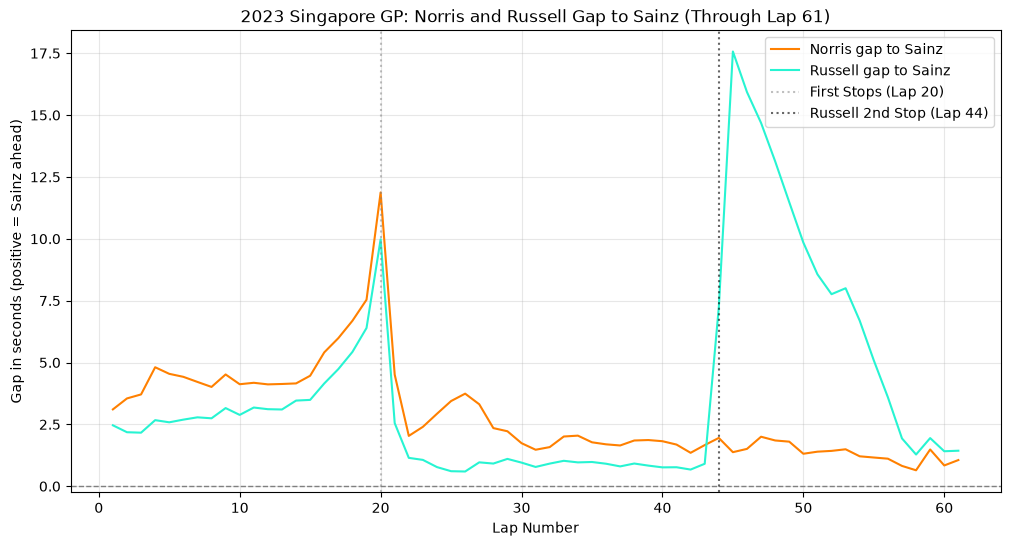

In [10]:
#Fixed chart since RUS lap 62 was a DNF lap and should not be included in the gap chart. I will filter out the DNF lap for RUS and re-plot the gap chart.

merged_clean = merged[merged['LapNumber'] < 62]

plt.figure(figsize=(12, 6))
plt.plot(merged_clean['LapNumber'], merged_clean['Gap_NOR_to_SAI'], color='#FF8000', label='Norris gap to Sainz')
plt.plot(merged_clean['LapNumber'], merged_clean['Gap_RUS_to_SAI'], color='#27F4D2', label='Russell gap to Sainz')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.axvline(20, color='gray', linestyle=':', alpha=0.5, label='First Stops (Lap 20)')
plt.axvline(44, color='black', linestyle=':', alpha=0.6, label='Russell 2nd Stop (Lap 44)')

plt.xlabel('Lap Number')
plt.ylabel('Gap in seconds (positive = Sainz ahead)')
plt.title('2023 Singapore GP: Norris and Russell Gap to Sainz (Through Lap 61)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()